In [1]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [2]:
# importing plotting and locus tools: 
import neoom as nf
import NEOMOD3 as nm3  

In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
import pyarrow as pa
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator

#importing the neomod3.py file for the 4D array
import NEOMOD3 as nm3

In [4]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [5]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 80.0, 20.0, 0.12, 0.22 
# add mag here
mag = 20.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [6]:

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 0.92266
a: 1.4547289094311036
e: 0.31736085318504975
i: 25.371763472565718


In [76]:
def comp_sum1():
    
    N_rate = 81           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf. ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()



/tmp/ipykernel_2053059/3546784570.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


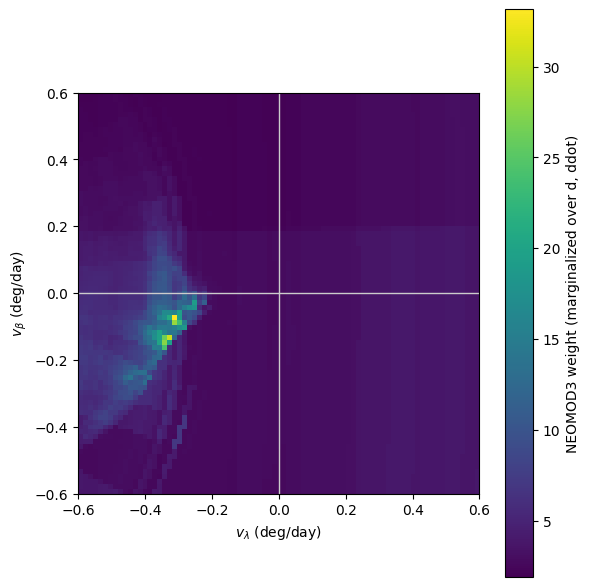

In [77]:
# VERSION WITH FLIPPED DRA VLAMBDA
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()



In [78]:
# setting value for phi = 0, beta = 0 
phi_deg = 0.0 # on the opposition
beta_deg = 0.0 # on the ecliptic


In [79]:
vE_deg_per_day = 0.986  # earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    # convert angles to radians
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    # from eqn A7 to A8
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    # heliocentric velocity components 
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    # ecliptic rates
    vlam =  (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet


In [72]:
print(len(R_lines), len(i_lines))
print(R_lines[0][0][:5], R_lines[0][1][:5])  \


SyntaxError: incomplete input (3558729226.py, line 2)

In [80]:
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU 

i_lines = []  # [vlam_arr, vbet_arr, i_deg]

for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


In [81]:
R_list = [2.0, 2.5, 3.0, 3.5]
i_pos = i_center[(i_center >= 0.0) & (i_center <= 40.0)]  # same i-range as neomod3
i_vals_for_R = np.concatenate((-i_pos[::-1], i_pos))
R_lines = []  # [vlam_arr, vbet_arr, R)]
for R in R_list:
    vlam_arr = []
    vbet_arr = []
    for i_deg in i_vals_for_R:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    R_lines.append((np.array(vlam_arr), np.array(vbet_arr), R))


/tmp/ipykernel_2053059/1930506286.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


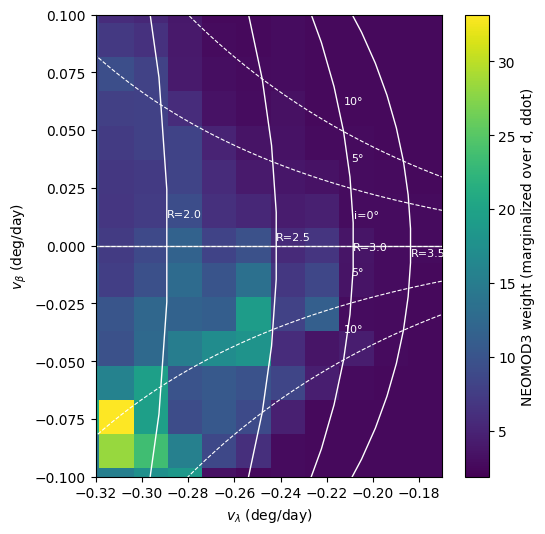

In [83]:
plt.figure(figsize=(6.0, 6.0))
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")
plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")
plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.32, -0.17)
plt.ylim(-0.1, 0.1)

# solid lines for R
for vlam_arr, vbet_arr, R in R_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=1.0)
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] - 0.012,  # a bit below the line
             f"R={R:.1f}", color="white", fontsize=8)

# dashed linesnfor i
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=0.8, ls="--")
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] + 0.012,
             f"{abs(i_deg):.0f}°" if i_deg != 0 else "i=0°",
             color="white", fontsize=8)